In [1]:
#!/usr/bin/env python3
import os
import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.training.errors import ErrorDict
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.data.hamiltonian_dataset import seeded_random_split
from equiv_dens.utils.grids import cubical_grid, cubical_sampling,\
    dftpy_grid, CubicalGrid, spherical_grid, spherical_radial_sampling
from equiv_dens.training.model_loader import load_model
import equiv_dens.utils.base as utils

import numpy as np
from functools import partial

%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/pyscf/lib/misc.py:47: H5pyDeprecationWarning: Using default_file_mode other than 'r' is deprecated. Pass the mode to h5py.File() instead.
  h5py.get_config().default_file_mode = 'a'


In [242]:
#args, hyperparam_args = parse_command_line_arguments(arg_file='ethanol_dens_001_mae_test.txt')
args, hyperparam_args = parse_command_line_arguments(arg_file='water_dyn_dens_2_test.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = args.use_gpu and torch.cuda.is_available()
np_dataset = np.load(args.np_dataset, allow_pickle=True).item()
min_pos = np.min(np_dataset['positions'])
print(min_pos)
max_pos = np.max(np_dataset['positions'])
print(max_pos)
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")
args.verbose = 0
args.use_gpu = False
args.cube_grid = True
args.radii_adjust = True 
if args.cube_grid:
    args.cube_origin = min_pos - 1
    args.cube_extent = max_pos-min_pos + 2
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=2)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=args.verbose,
                           radii_adjust=args.radii_adjust)

type dtype <class 'torch.dtype'>
args np dir datasets/h2o_dynamic_centered.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg integral_constraint
loading hyperparam arg integral_scale
loading hyperpar

In [243]:
# torch.manual_seed(0)
# np.random.seed(0)
# args.restart = None
args.partial_densities = True

In [244]:
model = load_model(args, dataset)

cg_matrix shape torch.Size([121, 121, 121])
args energy_unit_in kcal
args energy_unit_out kcal
conversions in <function kcal_to_kcal at 0x7fc1387228c8>
conversions out <function kcal_to_kcal at 0x7fc1387228c8>
self order [1, 1, 5]
self order [1, 1, 5]
self mixing_order [1, 1, 5]
self mixing_order [1, 1, 5]
Order needs to be an integer or a list of integers with length equal to num_modules. Taking last order element and using it for all modules.
Mixing order needs to be an integer or a list of integers with length equal to num_modules. Taking last order element and using it for all modules.
creating embedding
init_coeffs None
orbital basis {8: [(8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 0), (8, 1, 1), (8, 1, 1), (8, 1, 1), (8, 1, 1), (8, 1, 1), (8, 1, 1), (8, 1, 1), (8, 1, 1), (8, 1, 2), (8, 1, 2), (8, 1, 2), (8, 1, 2), (8, 1, 2), (8, 1, 2), (8, 1, 3), (8, 1, 3), (8, 1, 3), (8, 1, 3), (8, 1, 4), (8, 1, 4), (8, 1, 

In [245]:
sample_idx = 5

sample = dataset.get_properties([sample_idx])

In [246]:
sample['positions']
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))

density integral tensor(9.2335)


In [247]:
model.property_models['density'].expansion_constraint='sp'
result = model(sample)
print('density integral', torch.sum(result['density'] * result['coord_weights']))
print(result['coord_weights'])

partial densities True
coords shape torch.Size([1, 125000, 3])
density shape torch.Size([1, 125000])
coords type torch.FloatTensor
pos type torch.FloatTensor
coords type torch.FloatTensor
pos type torch.FloatTensor
coords type torch.FloatTensor
pos type torch.FloatTensor
density integrals [tensor([7.9992], grad_fn=<SumBackward1>), tensor([0.6174], grad_fn=<SumBackward1>), tensor([0.6173], grad_fn=<SumBackward1>)]
sum subzero tensor(4.6096, grad_fn=<SumBackward0>)
num subzero tensor(32259)
integral constraint True
expansion constraint sp
density integral tensor(9.2564, grad_fn=<SumBackward0>)
tensor([[0.0049, 0.0049, 0.0049,  ..., 0.0049, 0.0049, 0.0049]])


dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
torch.Size([1, 3, 125000])


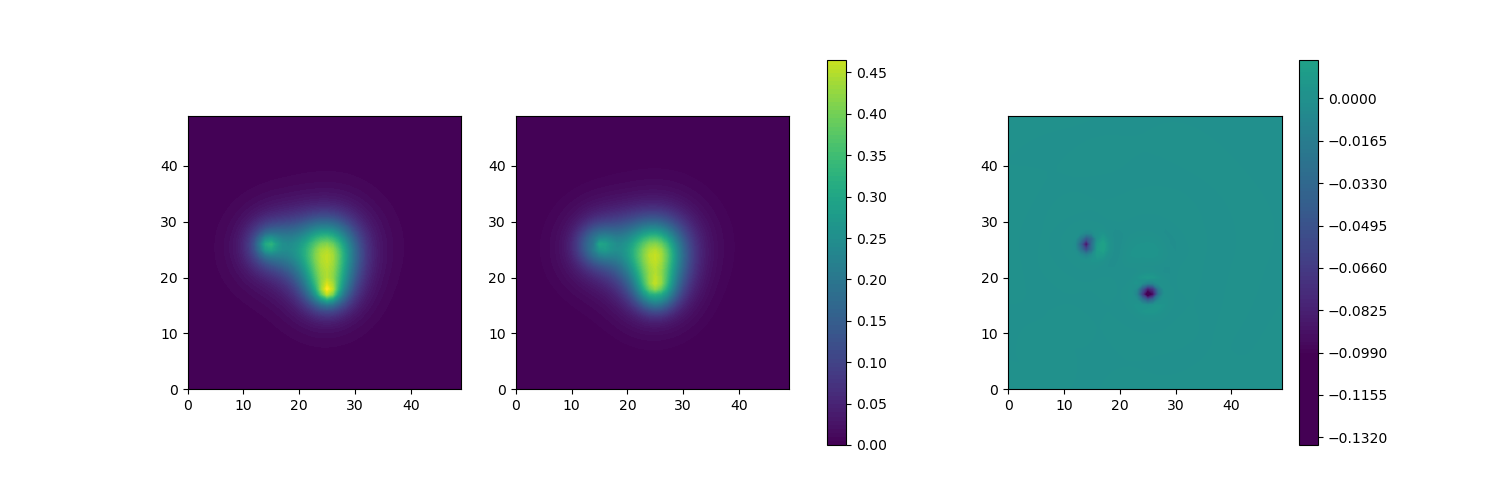

In [248]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
dens = np.array(sample['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = np.sum(result['density'].cpu().data.squeeze().numpy(), axis=0)

p_dens = p_dens[idx].reshape(50, 50)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

In [249]:
print('density diff integral', torch.sum(torch.abs((torch.sum(result['density'], dim=1) - sample['density'])) * result['coord_weights']))

density diff integral tensor(0.0774, grad_fn=<SumBackward0>)


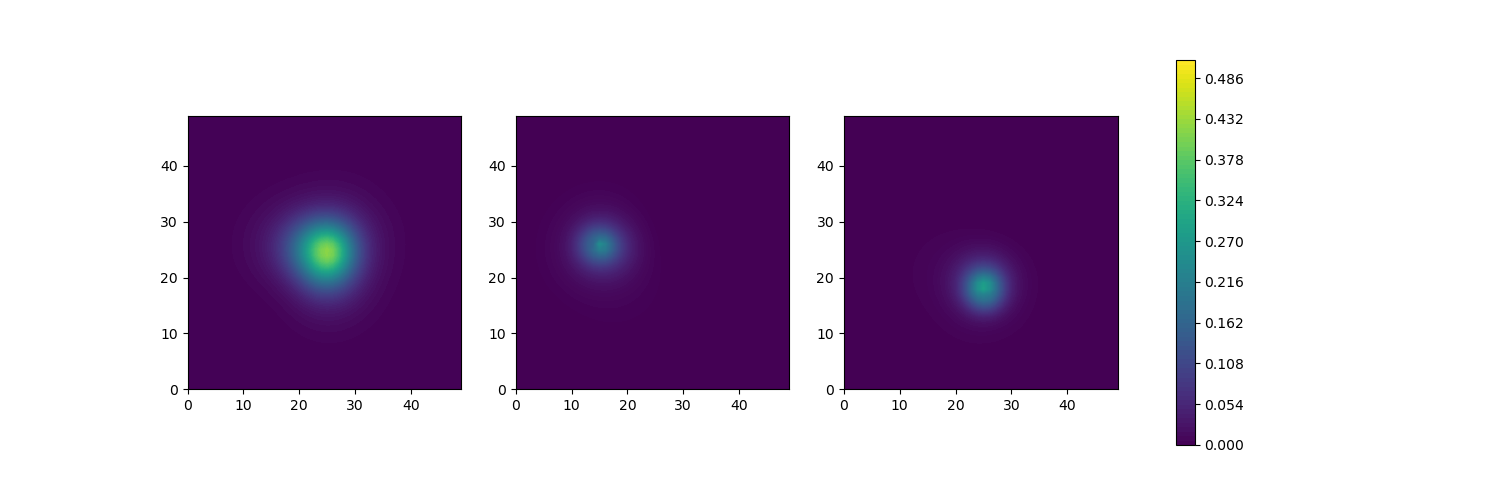

In [250]:

x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))

fig = plt.figure(figsize=(15, 5))
p_dens = result['density'].cpu().data.squeeze().numpy()

axs = []

for i in range(p_dens.shape[0]):
    
    dens = p_dens[i, idx].reshape(50, 50)
    ax = fig.add_subplot(1, p_dens.shape[0], i + 1)
    c = ax.contourf(x, y, dens, vmin=vmin, vmax=vmax, levels=100)
    ax.set_aspect('equal')
    axs.append(ax)


fig.colorbar(c1, ax=axs)
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

torch.Size([1, 3, 125000])
partial densities integrals tensor([[8.0001, 0.6250, 0.6313]], grad_fn=<SumBackward1>)
partial atom numers tensor([[8, 0, 0]])
partial densities True
coords shape torch.Size([1, 125000, 3])
density shape torch.Size([1, 125000])
coords type torch.FloatTensor
pos type torch.FloatTensor
density integrals [tensor([7.3745], grad_fn=<SumBackward1>), tensor([0.]), tensor([0.])]
sum subzero tensor(0., grad_fn=<SumBackward0>)
num subzero tensor(0)
integral constraint True
expansion constraint sp


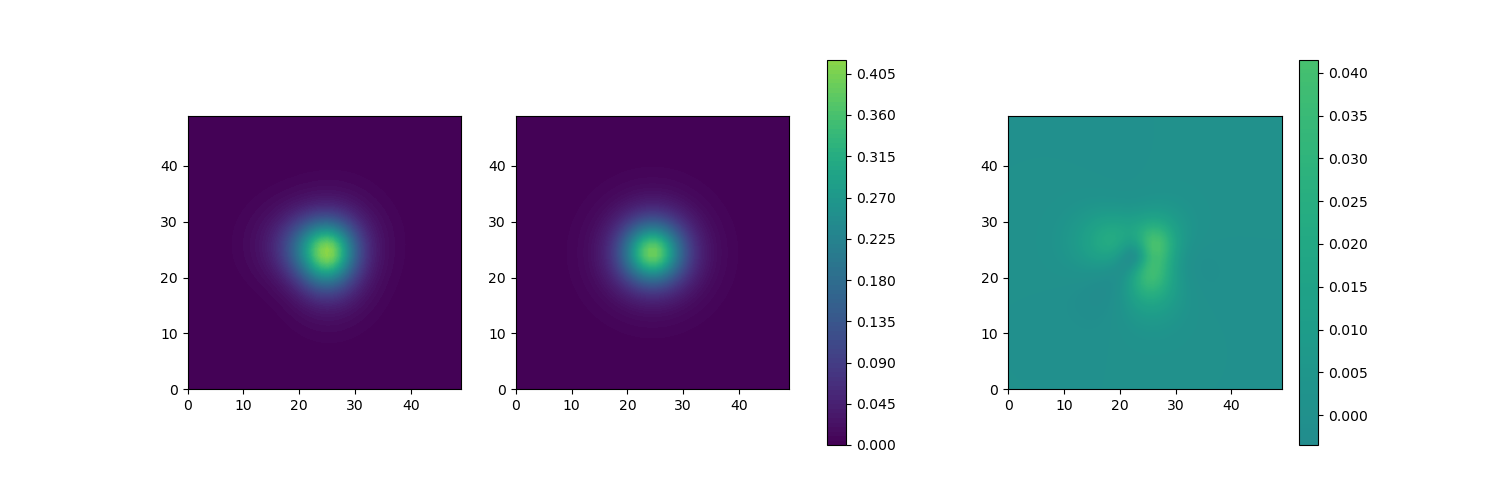

partial atom numers tensor([[0, 1, 0]])
partial densities True
coords shape torch.Size([1, 125000, 3])
density shape torch.Size([1, 125000])
coords type torch.FloatTensor
pos type torch.FloatTensor
density integrals [tensor([0.]), tensor([0.9244], grad_fn=<SumBackward1>), tensor([0.])]
sum subzero tensor(0., grad_fn=<SumBackward0>)
num subzero tensor(0)
integral constraint True
expansion constraint sp


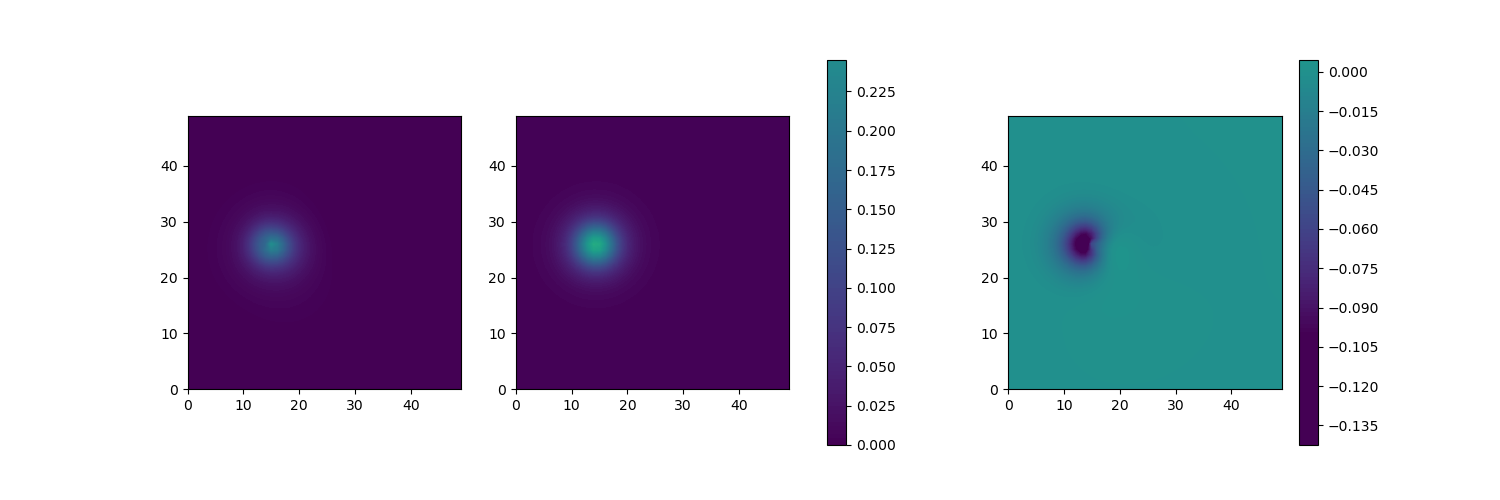

partial atom numers tensor([[0, 0, 1]])
partial densities True
coords shape torch.Size([1, 125000, 3])
density shape torch.Size([1, 125000])
coords type torch.FloatTensor
pos type torch.FloatTensor
density integrals [tensor([0.]), tensor([0.]), tensor([0.9297], grad_fn=<SumBackward1>)]
sum subzero tensor(0., grad_fn=<SumBackward0>)
num subzero tensor(0)
integral constraint True
expansion constraint sp


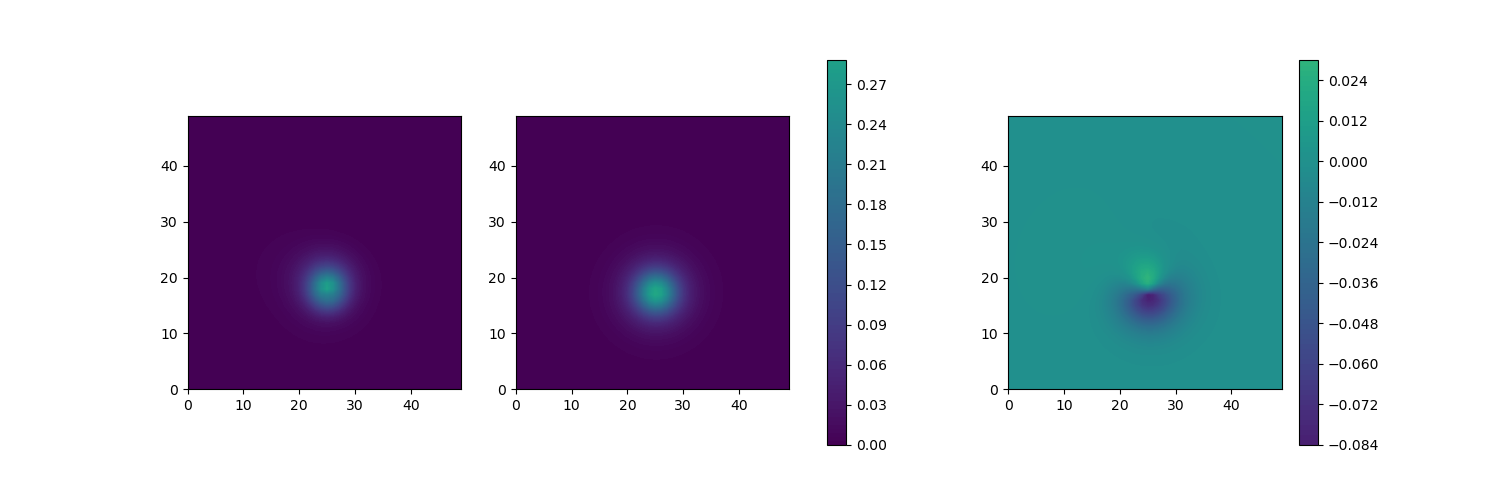

In [251]:

x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))


p_dens = result['density'].cpu().data.squeeze().numpy()
print(result['density'].shape)
print('partial densities integrals', torch.sum(result['density'] * result['coord_weights'], dim=-1))
for i in range(p_dens.shape[0]):
    fig = plt.figure(figsize=(15, 5))

    partial_sample = {}
    partial_sample['positions'] = sample['positions'].clone().detach()
    partial_sample['atom_numbers'] = torch.zeros_like(sample['atom_numbers'])
    partial_sample['atom_numbers'][:, i] = sample['atom_numbers'][0, i]
    partial_sample['atom_mask'] = partial_sample['atom_numbers'] != 0
    partial_sample['coords'] = sample['coords'].clone().detach()
    partial_sample['coord_weights'] = sample['coord_weights'].clone().detach()
    print('partial atom numers', partial_sample['atom_numbers'])
    
    partial_result = model(partial_sample)
    
    #dens = p_dens[i, idx].reshape(50, 50)
    dens = p_dens[i, idx].reshape(50, 50)
    ax1 = fig.add_subplot(1, 3, 1)
    c1 = ax1.contourf(x, y, dens, vmin=vmin, vmax=vmax, levels=100)
    ax1.set_aspect('equal')
    
    dens_part = partial_result['density'].cpu().data.squeeze().numpy()
    dens_part = dens_part[i, idx].reshape(50, 50)
    ax2 = fig.add_subplot(1, 3, 2)
    c2 = ax2.contourf(x, y, dens_part, vmin=vmin, vmax=vmax, levels=100)
    ax2.set_aspect('equal')
    
    ax3 = fig.add_subplot(133)
    c3 = ax3.contourf(x, y, dens-dens_part, vmin=-0.1, vmax=0.1, levels=100)
    ax3.set_aspect('equal')


    fig.colorbar(c1, ax=[ax1, ax2])
    fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
    plt.show()